### Introducción

Este notebook tendrá como finalidad presentar el entrenamiento de los modelos de regresión logística, árbol de decisión y random forest

### Importación de librerías

In [94]:
import os
import pickle
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)


### Definición de constantes

In [38]:
PATH_DIRECTORIO_DATOS = "../../data"
PATH_DIRECTORIO_DATOS_MODELADOS = f"{PATH_DIRECTORIO_DATOS}/processed"

In [39]:
PATH_DATASET_MODELADOS = f"{PATH_DIRECTORIO_DATOS_MODELADOS}/dataset_practica_final_modelado.csv"

In [62]:
PATH_MODELS_TESTS = '../../models/tests'

### Lectura de datos

In [40]:
df_reservas= pd.read_csv(PATH_DATASET_MODELADOS) 

In [41]:
df_reservas

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,...,adr,required_car_parking_spaces,total_of_special_requests,adults_categories,has_children,has_babies,arrival_season,month_period,arrival_quarter,country_grouped
0,Resort Hotel,0,342,0,0,BB,Direct,Direct,0,0,...,0.00,0,0,2 adultos,0,0,temporada_alta,inicio_mes,Q3,PRT
1,Resort Hotel,0,737,0,0,BB,Direct,Direct,0,0,...,0.00,0,0,2 adultos,0,0,temporada_alta,inicio_mes,Q3,PRT
2,Resort Hotel,0,7,0,1,BB,Direct,Direct,0,0,...,75.00,0,0,1 adulto,0,0,temporada_alta,inicio_mes,Q3,GBR
3,Resort Hotel,0,13,0,1,BB,Corporate,Corporate,0,0,...,75.00,0,0,1 adulto,0,0,temporada_alta,inicio_mes,Q3,GBR
4,Resort Hotel,0,14,0,2,BB,Online TA,TA/TO,0,0,...,98.00,0,1,2 adultos,0,0,temporada_alta,inicio_mes,Q3,GBR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118892,City Hotel,0,23,2,5,BB,Offline TA/TO,TA/TO,0,0,...,96.14,0,0,2 adultos,0,0,temporada_alta,fin_mes,Q3,BEL
118893,City Hotel,0,102,2,5,BB,Online TA,TA/TO,0,0,...,225.43,0,2,3 o más adultos,0,0,temporada_alta,fin_mes,Q3,FRA
118894,City Hotel,0,34,2,5,BB,Online TA,TA/TO,0,0,...,157.71,0,4,2 adultos,0,0,temporada_alta,fin_mes,Q3,DEU
118895,City Hotel,0,109,2,5,BB,Online TA,TA/TO,0,0,...,104.40,0,0,2 adultos,0,0,temporada_alta,fin_mes,Q3,GBR


### Regresión Logística

#### Creación del modelo y ajuste

Hacemos la preparación de los conjuntos de datos para las variables independientes y la variable objetivo. De esta forma podemos hacer el train test split.

In [42]:
# Separando las variables

X_reservas = df_reservas.drop(columns='is_canceled')
y_reservas = df_reservas['is_canceled']

In [43]:
# Realizando train test split con la opción stratify para que la proporción de clases se mantenga en los conjuntos train y test

X_train, X_test, y_train, y_test = train_test_split(X_reservas, y_reservas, test_size=0.2, random_state=42, stratify=y_reservas)



Definimos un preprocesador para hacer one-hot encoding y escalamiento. Se utiliza Grid Search para hacer validación cruzada y encontrar los mejores hiperparámetros

In [ ]:
# Definimos el preprocesador de one hot encoder y escalamiento (detecta tipos de datos de la columna de forma automática)
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
        make_column_selector(dtype_include=['object', 'category'])),
        ('num', StandardScaler(), 
        make_column_selector(dtype_include=['number']))
    ]
)

# Construimos el pipeline con el modelo de regresión logística
pipeline_rl = Pipeline(steps=[
    ('prep', preprocesador),
    ('modelo', LogisticRegression(random_state=42))
])

# Diccionario de parámetros adaptado para el Pipeline
rl_parametros = {
    'modelo__C': [0.01, 0.1, 1, 10],
    'modelo__solver': ['liblinear'],
    'modelo__max_iter': [100, 200, 500, 1000]
}

# Configuramos GridSearchCV pasando el Pipeline completo
modelo_rl_cv = GridSearchCV(
    estimator=pipeline_rl, 
    param_grid=rl_parametros, 
    cv=5, 
    scoring='f1', 
    n_jobs=-2,
    verbose=1
)

# Entrenamos el modelo
print("Realizando optimización con GridSearchCV...")
modelo_rl_cv.fit(X_train, y_train)

Iniciando optimización con GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F03934ED0>),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F4A026A10>)])),
                                       ('modelo',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-2,
             param_grid={'modelo__C': [0.01, 0.1, 1, 10],
                         'modelo__max_iter': [100, 200, 500, 1000],
                         'modelo__solver': ['liblinear']},
             scoring='f1', verbose=1)

#### Evaluación del modelo

In [55]:
# Imprimimos los parámetros que eligió como ganadores
print("Parámetros ganadores en el entrenamiento:", modelo_rl_cv.best_params_)
print(f"Mejor score obtenido en el entrenamiento: {modelo_rl_cv.best_score_:.2%}")

# Usamos el modelo ganador sobre los datos de prueba (Test)
y_pred = modelo_rl_cv.predict(X_test)

# Reporte de métricas
print("\n--- REPORTE DE EVALUACIÓN FINAL ---")
print(classification_report(y_test, y_pred, digits=4))

Parámetros ganadores en el entrenamiento: {'modelo__C': 10, 'modelo__max_iter': 100, 'modelo__solver': 'liblinear'}
Mejor score obtenido en el entrenamiento: 72.43%

--- REPORTE DE EVALUACIÓN FINAL ---
              precision    recall  f1-score   support

           0     0.8174    0.9061    0.8595     14949
           1     0.8052    0.6573    0.7238      8831

    accuracy                         0.8137     23780
   macro avg     0.8113    0.7817    0.7916     23780
weighted avg     0.8129    0.8137    0.8091     23780



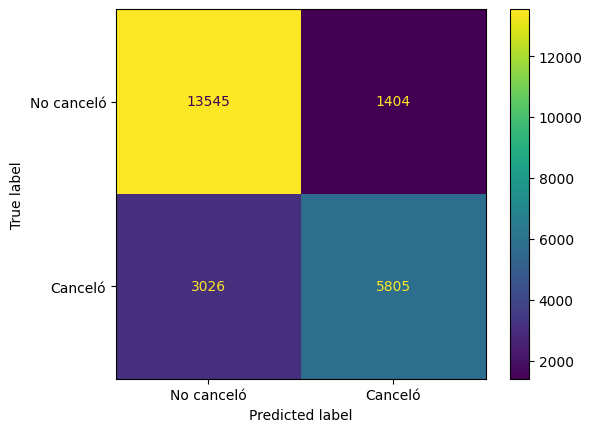

In [56]:
# Mostramos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No canceló', 'Canceló'])
disp.plot()
plt.show()

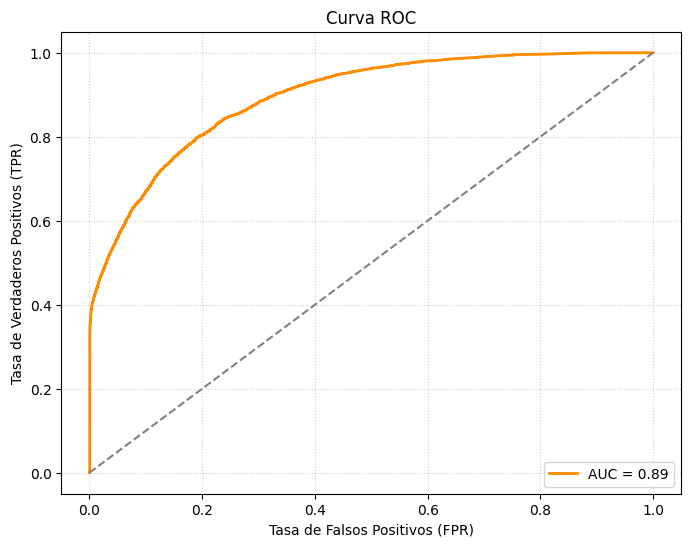

In [ ]:
# Curva ROC

y_proba = modelo_rl_cv.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)


fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Exportando el modelo

Se procede a exportar el mejor modelo como un archivo .pkl

In [65]:
# Determinamos la ruta de destino del archivo.pkl y su nombre

nombre_archivo_pkl = 'modelo_regresion_logistica_caso_inicial.pkl'
ruta_completa = os.path.join(PATH_MODELS_TESTS, nombre_archivo_pkl)

# Aseguram que la ruta exista (si no existe, la crea automáticamente)
os.makedirs(PATH_MODELS_TESTS, exist_ok=True)

# Guardamos el mejor estimador del GridSearchCV en la ruta específica
with open(ruta_completa, 'wb') as archivo_pkl:
    pickle.dump(modelo_rl_cv.best_estimator_, archivo_pkl)

print(f"¡El modelo de regresión logística (caso inicial) se ha guardado correctamente!")

¡El modelo de regresión logística (caso inicial) se ha guardado correctamente!


### Árbol de Decisión

#### Creación del modelo y ajuste

Procedemos a realizar el entrenamiento del modelo basándonos en las variables X_train y X_test que ya tenemos separadas y procesadas. Entrenamos el árbol de decisión usando GridSearchCV para encontrar los mejores hiperparámetros

In [67]:
# Construimos el pipeline con el modelo de árbol de decisión
pipeline_dt = Pipeline(steps=[
    ('prep', preprocesador),
    ('modelo', DecisionTreeClassifier(random_state=42))
])

# Diccionario de parámetros 
dt_parametros = {
    'modelo__max_depth': [2, 3, 5, 7, 10, 20, None],
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__min_samples_split': [2, 5, 10, 20, 50],
    'modelo__min_samples_leaf': [1, 2, 4, 8]
}

# Configuramos GridSearchCV pasando el Pipeline completo
modelo_dt_cv = GridSearchCV(
    estimator=pipeline_dt, 
    param_grid=dt_parametros, 
    cv=5, 
    scoring='f1', 
    n_jobs=-2,
    verbose=1
)

# Entrenamos el modelo
print("Realizando optimización con GridSearchCV...")
modelo_dt_cv.fit(X_train, y_train)

Realizando optimización con GridSearchCV...
Fitting 5 folds for each of 280 candidates, totalling 1400 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F03934ED0>),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F4A026A10>)])),
                                       ('modelo',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-2,
             param_grid={'modelo__criterion': ['gini', 'entropy'],
                         'modelo__max_depth': [2, 3, 5, 7, 10, 20, None],
                         'modelo__min_samples_leaf': [1, 2, 4, 8],
                         'modelo__min_samples_split': [2, 5, 10, 20, 50]},
             scoring='f1', verbose=1)

#### Evaluación del modelo

In [68]:
# Vemos cuáles son los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_dt_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_dt_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'modelo__criterion': 'gini', 'modelo__max_depth': 20, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}
Mejor score obtenido: 78.76%


In [69]:
# Usamos el modelo ganador sobre los datos de prueba (Test)
y_pred = modelo_dt_cv.predict(X_test)

# Reporte de métricas
print("\n--- REPORTE DE EVALUACIÓN FINAL ---")
print(classification_report(y_test, y_pred, digits = 4))


--- REPORTE DE EVALUACIÓN FINAL ---
              precision    recall  f1-score   support

           0     0.8744    0.8875    0.8809     14949
           1     0.8046    0.7842    0.7942      8831

    accuracy                         0.8491     23780
   macro avg     0.8395    0.8358    0.8376     23780
weighted avg     0.8485    0.8491    0.8487     23780



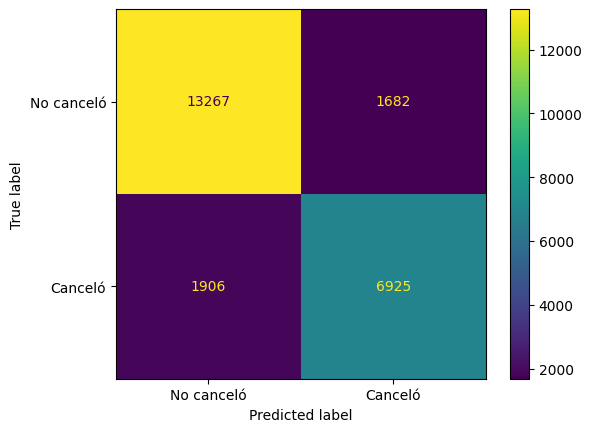

In [70]:
# Mostramos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No canceló', 'Canceló'])
disp.plot()
plt.show()

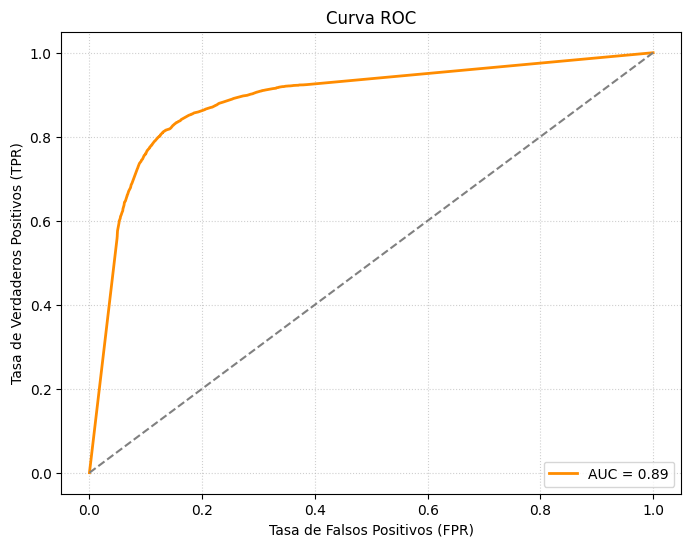

In [71]:
# Curva ROC

y_proba = modelo_dt_cv.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Exportando el modelo

Se procede a exportar el mejor modelo como un archivo .pkl

In [ ]:
# Determinamos la ruta de destino del archivo.pkl y su nombre

nombre_archivo_pkl = 'modelo_arbol_decision_caso_inicial.pkl'
ruta_completa = os.path.join(PATH_MODELS_TESTS, nombre_archivo_pkl)

# Aseguram que la ruta exista (si no existe, la crea automáticamente)
os.makedirs(PATH_MODELS_TESTS, exist_ok=True)

# Guardamos el mejor estimador del GridSearchCV en la ruta específica
with open(ruta_completa, 'wb') as archivo_pkl:
    pickle.dump(modelo_dt_cv.best_estimator_, archivo_pkl)

print(f"¡El modelo de árbol de decisión (caso inicial) se ha guardado correctamente!")

¡El modelo de árbol de decisión (caso inicial) se ha guardado correctamente!


### Random Forest

#### Creación del modelo y ajuste

Procedemos a realizar el entrenamiento del modelo basándonos en las variables X_train y X_test que ya tenemos separadas y procesadas. Entrenamos el modelo de random forest usando GridSearchCV para encontrar los mejores hiperparámetros.

In [88]:
# Construimos el pipeline con el modelo de árbol de decisión
pipeline_rfc = Pipeline(steps=[
    ('prep', preprocesador),
    ('modelo', RandomForestClassifier(random_state=42))
])

# Diccionario de parámetros 
rfc_parametros = {
    'modelo__n_estimators': [50, 150, 200],
    'modelo__max_depth': [10, 15, 20, 50],
    'modelo__min_samples_split': [10, 20],
    'modelo__min_samples_leaf': [5, 10]
}

# Configuramos GridSearchCV pasando el Pipeline completo
modelo_rfc_cv = GridSearchCV(
    estimator=pipeline_rfc, 
    param_grid=rfc_parametros, 
    cv=5, 
    scoring='f1', 
    n_jobs=-2,
    verbose=1
)

# Entrenamos el modelo
print("Realizando optimización con GridSearchCV...")
modelo_rfc_cv.fit(X_train, y_train)

Realizando optimización con GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F03934ED0>),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F4A026A10>)])),
                                       ('modelo',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-2,
             param_grid={'modelo__max_depth': [10, 15, 20, 50],
                         'modelo__min_samples_leaf': [5, 10],
                         'modelo__min_samples_split': [10, 20],
                         'modelo__n_estimators': [50, 150, 200]},
             scoring='f1', verbose=1)

#### Evaluación del modelo

In [89]:
# Vemos cuáles son los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_rfc_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_rfc_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'modelo__max_depth': 50, 'modelo__min_samples_leaf': 5, 'modelo__min_samples_split': 10, 'modelo__n_estimators': 150}
Mejor score obtenido: 80.18%


In [90]:
# Usamos el modelo ganador sobre los datos de prueba (Test)
y_pred = modelo_rfc_cv.predict(X_test)

# Reporte de métricas
print("\n--- REPORTE DE EVALUACIÓN FINAL ---")
print(classification_report(y_test, y_pred, digits = 4))


--- REPORTE DE EVALUACIÓN FINAL ---
              precision    recall  f1-score   support

           0     0.8634    0.9377    0.8990     14949
           1     0.8766    0.7488    0.8077      8831

    accuracy                         0.8676     23780
   macro avg     0.8700    0.8433    0.8534     23780
weighted avg     0.8683    0.8676    0.8651     23780



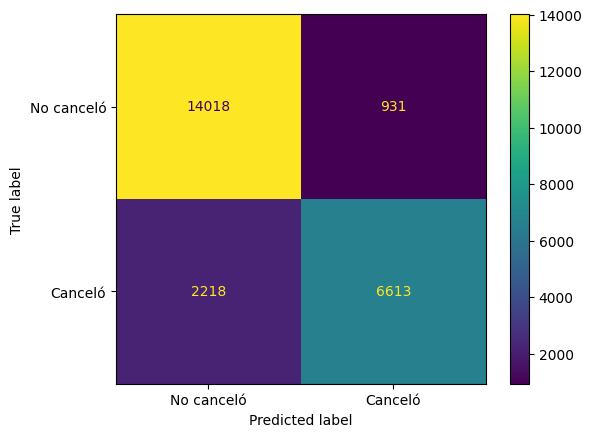

In [91]:
# Mostramos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No canceló', 'Canceló'])
disp.plot()
plt.show()

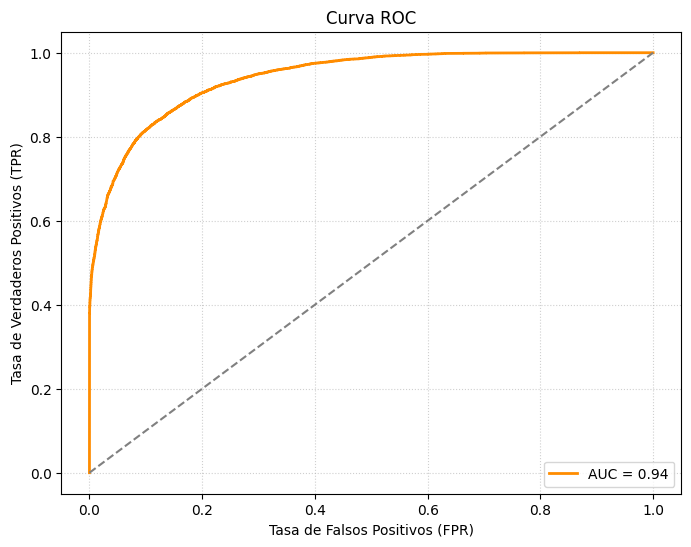

In [92]:
# Curva ROC

y_proba = modelo_rfc_cv.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)


fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Exportando el modelo

Se procede a exportar el mejor modelo como un archivo .pkl

In [93]:
# Determinamos la ruta de destino del archivo.pkl y su nombre

nombre_archivo_pkl = 'modelo_random_forest_caso_inicial.pkl'
ruta_completa = os.path.join(PATH_MODELS_TESTS, nombre_archivo_pkl)

# Aseguram que la ruta exista (si no existe, la crea automáticamente)
os.makedirs(PATH_MODELS_TESTS, exist_ok=True)

# Guardamos el mejor estimador del GridSearchCV en la ruta específica
with open(ruta_completa, 'wb') as archivo_pkl:
    pickle.dump(modelo_rfc_cv.best_estimator_, archivo_pkl)

print(f"¡El modelo de random forest (caso inicial) se ha guardado correctamente!")

¡El modelo de random forest (caso inicial) se ha guardado correctamente!


### Regresión Logística con PCA

#### Creación del modelo y ajuste

Procedemos a realizar el entrenamiento del modelo basándonos en las variables X_train y X_test que ya tenemos separadas y procesadas. Integraremos al pipeline la reducción de dimensionalidad con PCA adicionalmente al one-hot encoder y al escalamiento que ya tenemos. Entrenamos el modelo de regresión logística usando GridSearchCV para encontrar los mejores hiperparámetros

In [100]:
# Definimos el preprocesador de one hot encoder y escalamiento (detecta tipos de datos de la columna de forma automática)
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
        make_column_selector(dtype_include=['object', 'category'])),
        ('num', StandardScaler(), 
        make_column_selector(dtype_include=['number']))
    ]
)

# Construimos el pipeline con el modelo de regresión logística añadiendo PCA 
pipeline_rl_pca = Pipeline(steps=[
    ('prep', preprocesador),
    ('pca',PCA(random_state=42)),
    ('modelo', LogisticRegression(random_state=42))
])

# Diccionario de parámetros adaptado para el Pipeline
rl_pca_parametros = {
    'pca__n_components': [0.80, 0.90],
    'modelo__C': [0.01, 0.1, 1, 10],
    'modelo__solver': ['liblinear'],
    'modelo__max_iter': [100, 200, 500, 1000]
}

# Configuramos GridSearchCV pasando el Pipeline completo
modelo_rl_pca_cv = GridSearchCV(
    estimator=pipeline_rl_pca, 
    param_grid=rl_pca_parametros, 
    cv=5, 
    scoring='f1', 
    n_jobs=-2,
    verbose=1
)

# Entrenamos el modelo
print("Realizando optimización añadiendo PCA con GridSearchCV...")
modelo_rl_pca_cv.fit(X_train, y_train)

Realizando optimización añadiendo PCA con GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F686BF090>),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F4B915A10>)])),
                                       ('pca', PCA(random_state=42)),
                                       ('modelo',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-2,
             param_grid={'modelo__C': [0.01, 0.1, 1, 10],
                         'modelo__max_iter': [100, 200, 500, 1000],
                         'modelo__solver': ['liblinear'],
                         'pca__n_components': [0.8, 0.9]},
             scoring='f1', verbose=1)

#### Evaluación del modelo

In [109]:
# Imprimimos los parámetros que eligió como ganadores
print("Parámetros ganadores en el entrenamiento:", modelo_rl_pca_cv.best_params_)

# Extraemos el mejor pipeline ya entrenado
mejor_pipeline = modelo_rl_pca_cv.best_estimator_

# Accedemos al paso específico del PCA dentro de ese pipeline
pca_entrenado = mejor_pipeline.named_steps['pca']

# Calculamos cuantas columnas teniamos despues de hacer one-hot encoding, que son las columnas que entraron al paso de PCA
columnas_post_ohe = pca_entrenado.n_features_in_

# Imprimimos la cantidad real de componentes despues de one-hot encoding vs componentes resultantes despues de PCA
print(f"\nColumnas tras procesamiento de One-Hot Encoding + Escalamiento: {columnas_post_ohe}")
print(f"El modelo final con PCA se quedó con {pca_entrenado.n_components_} componentes principales.")


print(f"\nMejor score obtenido en el entrenamiento: {modelo_rl_pca_cv.best_score_:.2%}")

# Usamos el modelo ganador sobre los datos de prueba (Test)
y_pred = modelo_rl_pca_cv.predict(X_test)

# Reporte de métricas
print("\n--- REPORTE DE EVALUACIÓN FINAL ---")
print(classification_report(y_test, y_pred, digits=4))

Parámetros ganadores en el entrenamiento: {'modelo__C': 1, 'modelo__max_iter': 100, 'modelo__solver': 'liblinear', 'pca__n_components': 0.9}

Columnas tras procesamiento de One-Hot Encoding + Escalamiento: 77
El modelo final con PCA se quedó con 23 componentes principales.

Mejor score obtenido en el entrenamiento: 70.73%

--- REPORTE DE EVALUACIÓN FINAL ---
              precision    recall  f1-score   support

           0     0.8115    0.8954    0.8514     14949
           1     0.7854    0.6478    0.7100      8831

    accuracy                         0.8035     23780
   macro avg     0.7984    0.7716    0.7807     23780
weighted avg     0.8018    0.8035    0.7989     23780



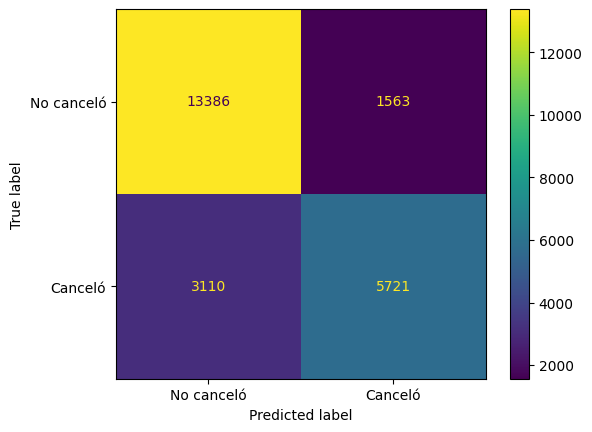

In [103]:
# Mostramos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No canceló', 'Canceló'])
disp.plot()
plt.show()

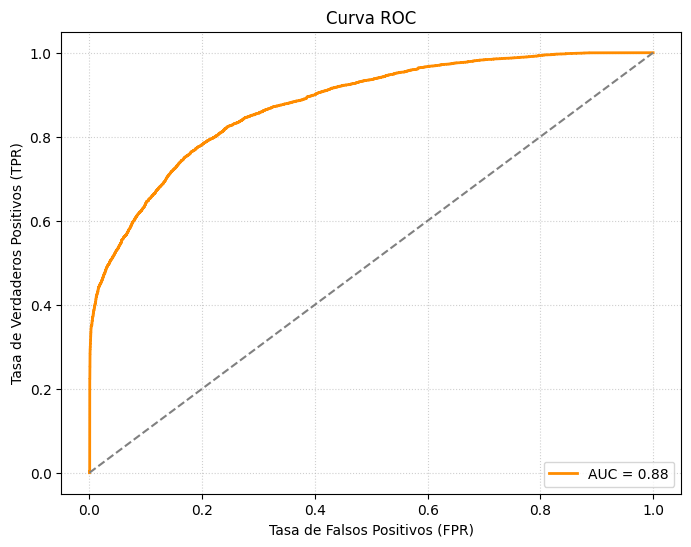

In [104]:
# Curva ROC

y_proba = modelo_rl_pca_cv.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)


fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Exportando el modelo

Se procede a exportar el mejor modelo como un archivo .pkl

In [110]:
# Determinamos la ruta de destino del archivo.pkl y su nombre

nombre_archivo_pkl = 'modelo_regresion_logistica_caso_pca.pkl'
ruta_completa = os.path.join(PATH_MODELS_TESTS, nombre_archivo_pkl)

# Aseguram que la ruta exista (si no existe, la crea automáticamente)
os.makedirs(PATH_MODELS_TESTS, exist_ok=True)

# Guardamos el mejor estimador del GridSearchCV en la ruta específica
with open(ruta_completa, 'wb') as archivo_pkl:
    pickle.dump(modelo_rl_pca_cv.best_estimator_, archivo_pkl)

print(f"¡El modelo de regresión logística (caso pca) se ha guardado correctamente!")

¡El modelo de regresión logística (caso pca) se ha guardado correctamente!
